## Importing and Initial Variables

In [2]:
import pandas as pd
from utils import credentials as cd, config as config
from dateutil import parser as dateparser
import requests
from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt

COLUMN_TEMPLATE = config.TODOIST_COLUMNS
FILENAME = "my-energysystem-tasks.csv"
COLUMNS_RENAMED = dict(zip(config.TODOIST_COLUMNS['keep'],config.TODOIST_COLUMNS['renamed']))
mostrecentdate = None
df = None
data_path = Path(Path.cwd(),r"data/",FILENAME)
baseurl = "https://api.todoist.com/api/v1/"
get_tasks = "tasks/completed/by_completion_date/"
get_projects = "projects/"
date_format = r"%Y/%m/%d"
headers = {"Authorization": f"Bearer {cd.api_key}"}

request_body = {
    "since" : None,
    "until" : None,
    "limit": "200"
}

In [3]:
len(config.TODOIST_COLUMNS['keep']) == len(config.TODOIST_COLUMNS['renamed'])

True

In [4]:
Path.exists(data_path)

True

## Functions

In [5]:
def isoToString(date, format):
    input_date = dateparser.parse(date)
    return input_date.strftime(format=format)

def column_is_type(df):
    return df.transform(lambda x: x.apply(type)).drop_duplicates().iloc[0]

def split_column(data,split,key):
    test = data[[key,split]]
    test = test[test.iloc[:, 1].notna()]
    # print(column_is_type(test.iloc[:,1]))
    if column_is_type(test.iloc[:,1]) is dict:
        unnest = test[split].apply(pd.Series)
        source_names = unnest.columns.tolist()
        updated_names = [split.capitalize() + part.capitalize() for part in source_names]

        rename_zip = zip(source_names, updated_names)
        rename_dict = dict(rename_zip)

        renamed = unnest.rename(rename_dict, axis=1)
        output = test.join(renamed)
        return output

def todistRequest(request, param, header):
    items = []
    result_type = "items"
    cursor = None
    if 'project' in request:
            result_type = "results"
    url = baseurl + request
    while True:
        params = param
        if cursor:
            params["cursor"] = cursor

        response = requests.get(url, params=params, headers=header)
        response.raise_for_status()
        data = response.json()

        items.extend(data.get(result_type))

        cursor = data.get("next_cursor")
        if not cursor:
            break
    return items

## Check for existing archive of tasks

In [6]:
# Path.read_bytes(data_path)
if Path.exists(data_path) is False:
    print("file not found.\npull from earliest month start.")
else:
    print("file found. Opening to collect last task date")
    df = pd.read_csv(data_path).infer_objects()
    mostrecentdate = df['CompletedDate'].max()
    

file found. Opening to collect last task date


In [7]:
# df.columns.to_list()

In [8]:
COLUMN_TEMPLATE['renamed']

['CreatedDate',
 'SubtaskOrder',
 'CompletedDate',
 'TaskContent',
 'TaskDetails',
 'TaskDuration',
 'TaskID',
 'TaskLabels',
 'NoteCount',
 'ParentTaskID',
 'ProjectID',
 'TaskPriority',
 'UpdatedDate',
 'DueDate',
 'IsRecurringTask']

### Grab the last completed date as a starting point to pull more tasks

In [9]:
end_date = datetime.now()

if mostrecentdate is None:
    print("No most recent date found")
    start_date = datetime.now()
    start_date = datetime.replace(start_date,day=1)
else:    
    mostrecentdate = dateparser.parse(mostrecentdate)
    start_date = mostrecentdate
    
iso_start_date = start_date.isoformat()
iso_end_date = end_date.isoformat()
    # datetime.strptime("5/1/2026","%m/%d/%Y")
# end_date = datetime.strptime("5/18/2026","%m/%d/%Y")



## Collect Project and Tasks

In [10]:
request_body['since'] = start_date
request_body['until'] = end_date

In [11]:
project_request = request_body

projects = todistRequest(get_projects, project_request, headers)
proj_df = pd.DataFrame(projects)
proj_df = proj_df[['id','name']]
proj_df.rename(columns={"name":"ProjectName","id":"ProjectID"},inplace=True)
proj_df

,ProjectID,ProjectName
0,6Mw9JcR2gjPR3Xjm,Inbox
1,6XQ4r58cjq52mMvR,THIS WEEK
2,6XQ4rFJqXG3g4VH9,NEXT WEEK
3,6XQ4rFr9QRhXRMj7,THIS MONTH
4,6XQ4rGM3VhmcrvWQ,NEXT MONTH
5,6XQ4rH982p3r3H2g,LONG-TERM | ON HOLD
6,6gRgWCHV3JgFVpxH,PLANNING
7,6gRgWG8Hh74482vX,ROUTINES


In [12]:
items = todistRequest(get_tasks,request_body,headers)

## Build Task Table

In [13]:
task_table = pd.DataFrame(items)

# if df is not None:
#     task_table = pd.concat([task_table,df])

task_table = task_table.reset_index(drop=True)
# task_table


In [14]:
id_column = (task_table.columns.get_loc("id"), "id")

## Split due date iterable into unique columns

In [15]:
date_columns = split_column(data=task_table,split='due',key=id_column[1])

if date_columns is not None:
    date_columns['DueDate'] = date_columns['DueDate'].apply(dateparser.parse)
    date_columns['DueDate'] = [date.strftime(date_format) for date in date_columns['DueDate']]
    combined_df = pd.merge(left=task_table, right=date_columns, on=id_column[1],how='left')
# combined_df

In [16]:
dates_to_convert = ['added_at', 'completed_at','updated_at']

combined_df[dates_to_convert] = combined_df[dates_to_convert].apply(lambda row: [isoToString(rowItem,date_format) for rowItem in row])

In [17]:
full_data = pd.merge(left=combined_df, right=proj_df,how='left',left_on="project_id",right_on='ProjectID')
# full_data
# proj_df

In [18]:
full_data.columns

Index(['added_at', 'added_by_uid', 'assigned_by_uid', 'checked', 'child_order',
       'completed_at', 'completed_by_uid', 'completed_count', 'content',
       'day_order', 'deadline', 'description', 'due_x', 'duration', 'goal_ids',
       'id', 'is_collapsed', 'is_deleted', 'labels', 'note_count', 'parent_id',
       'postponed_count', 'priority', 'project_id', 'responsible_uid',
       'section_id', 'updated_at', 'user_id', 'due_y', 'DueDate',
       'DueIs_recurring', 'DueLang', 'DueString', 'DueTimezone', 'ProjectID',
       'ProjectName'],
      dtype='str')

In [19]:
# for column in COLUMN_TEMPLATE['renamed']:
#     if column not in final_df:
#         print(f"column not found: {column}")

## Drop Raw data & Unneeded columns

In [20]:
final_df = full_data.drop(columns=COLUMN_TEMPLATE['drop'], errors="ignore")

final_df = final_df.rename(columns=COLUMNS_RENAMED)

final_df['IsRecurringTask'] = final_df['IsRecurringTask'].fillna(value=False)
final_df['DueDate'] = final_df['DueDate'].fillna("1900/01/01")
final_df['TaskDuration'] = final_df['TaskDuration'].fillna(0)
final_df['ParentTaskID'] = final_df['ParentTaskID'].fillna(value="")
final_df = final_df[list(COLUMNS_RENAMED.values())]
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CreatedDate      7 non-null      str   
 1   SubtaskOrder     7 non-null      int64 
 2   CompletedDate    7 non-null      str   
 3   TaskContent      7 non-null      str   
 4   TaskDetails      7 non-null      str   
 5   TaskDuration     7 non-null      object
 6   TaskID           7 non-null      str   
 7   TaskLabels       7 non-null      object
 8   NoteCount        7 non-null      int64 
 9   ParentTaskID     7 non-null      str   
 10  ProjectID        7 non-null      str   
 11  TaskPriority     7 non-null      int64 
 12  UpdatedDate      7 non-null      str   
 13  DueDate          7 non-null      str   
 14  IsRecurringTask  7 non-null      object
dtypes: int64(3), object(3), str(9)
memory usage: 972.0+ bytes


In [21]:
if df is None:
    final_df.to_csv(data_path,index=False)
else:
    for i, row in final_df.iterrows():
        if row['TaskID'] not in df['TaskID'].values:
            print(f"Task {row['TaskID']} not in existing tasks")
            row_to_append = row.to_frame().T
            row_to_append.to_csv(data_path,mode='a',index=False,header=False)
            refreshed_df = pd.concat([df,row.to_frame().T], ignore_index=True)
        else:
            refreshed_df = df

Task 6gp665rvqqqf2JmX not in existing tasks
Task 6gmfCvh3JMhHmcH2 not in existing tasks
Task 6cvfmPjfj2c6PX5j not in existing tasks


# Make some graphs

In [22]:
char_to_replace = {
    "[": "",
    "]": "",
    "'": "", 
    #", ": ""
}
refreshed_df['TaskLabels'] = refreshed_df['TaskLabels'].str.replace(char_to_replace)
refreshed_df['TaskLabels']

0                            energy_medium, recharging
1                             depleting, energy_medium
2      delayed gratification, depleting, energy_medium
3                 energy_low, recharging, relationship
4                            energy_medium, recharging
                            ...                       
184                   depleting, energy_medium, social
185                     energy_medium, fun, recharging
186                                                   
187                              depleting, energy_low
188                              depleting, energy_low
Name: TaskLabels, Length: 189, dtype: str

In [27]:
exploding = refreshed_df['TaskLabels'].str.split(",")
exploded = exploding.explode()

In [42]:
exploded = exploded.str.strip()

In [63]:
tag_counts = exploded.value_counts().reset_index(name='count')
tag_counts.columns = ['Tag', 'Count']
tag_counts['Tag'] = tag_counts['Tag'].replace("","unknown")

In [64]:
unique_tags = tag_counts['Tag'].drop_duplicates()
unique_tags = unique_tags.str.strip()
unique_tags.sort_values()



10                   career
3     delayed gratification
1                 depleting
6               energy_high
2                energy_low
0             energy_medium
9                       fun
5                     quick
4                recharging
7              relationship
8                    social
12                  unknown
11                   zombie
Name: Tag, dtype: str

In [45]:
tag_counts

,Tag,Count
0,energy_medium,87
1,depleting,86
2,energy_low,64
3,delayed gratification,49
4,recharging,36
5,quick,34
6,energy_high,28
7,relationship,23
8,social,20
9,fun,18


In [61]:
tag_counts.sort_values(by="Tag")

,Tag,Count,color
12,,4,Grey
10,career,18,lavender
3,delayed gratification,49,orangered
1,depleting,86,Red
6,energy_high,28,Blue
2,energy_low,64,Gold
0,energy_medium,87,Orange
9,fun,18,Teal
5,quick,34,azure
4,recharging,36,Green


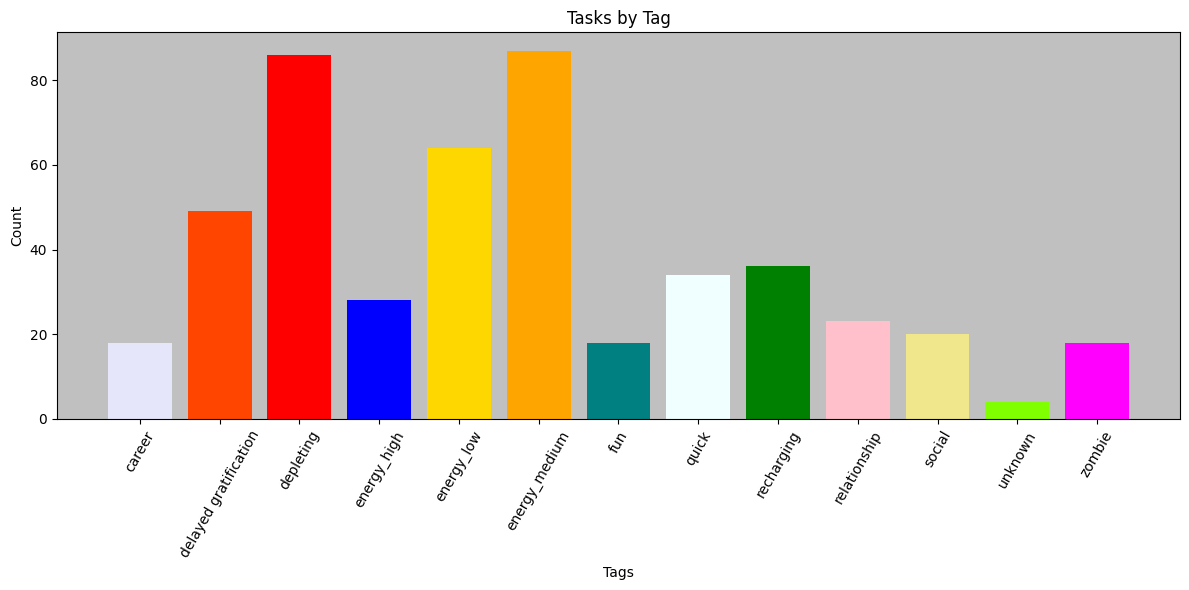

In [66]:
tag_color_map = {
    'delayed gratification': 'orangered',  # Dark Orange
    'depleting': 'Red',  # Red
    'career': 'lavender',  # Purple
    'energy_low': 'Gold',  # Gold
    'energy_medium': "Orange",  # Orange
    'energy_high': 'Blue',  # Blue
    'fun': 'Teal',  # Teal
    'quick': 'azure',  # Dark Green
    'recharging': 'Green',  # Green
    'relationship': 'pink',  # Navy
    'social': 'khaki',  # Cyan
    'zombie': 'Magenta',  # Magenta,
    'unknown': 'chartreuse'
}

tag_counts['color'] = tag_counts['Tag'].map(tag_color_map)

tag_counts = tag_counts.sort_values('Tag')
# # Optional: Generate more colors dynamically
plt.figure(figsize=(12,6),)
bars = plt.bar(tag_counts['Tag'], tag_counts['Count'], color = tag_counts['color'])


plt.xlabel('Tags')
plt.ylabel('Count')
plt.title('Tasks by Tag')
plt.xticks(rotation=60)
plt.tight_layout()

ax = plt.gca()
ax.set_facecolor("silver")
plt.show()